# Counting Methods in NLP

### Bag of Words · TF-IDF · N-grams
---

## Goal

In this notebook we explore the simplest and most foundational techniques for
representing text as numbers. These methods require no training, no neural
networks, and no GPU — just counting, weighting, and a bit of linear algebra.

We will use a real corpus of **91 Holberton School knowledge base articles** as
our dataset. This is the same corpus we will use later to build a Question
Answering bot — so understanding how these techniques see the data is essential
groundwork for everything that follows.

## Objectives

By the end of this notebook you will be able to:

- Load and preprocess a collection of real-world `.md` documents into a clean corpus
- Build a **Bag of Words** matrix and understand what it captures and what it misses
- Apply **TF-IDF** weighting and extract the most distinctive keywords per document
- Extract **N-grams** and observe how vocabulary size explodes with sequence length
- Compute **document similarity** using cosine similarity and visualize it as a heatmap
- Articulate clearly why these methods fail on semantic similarity —
  and what that means for the next notebook

## Dataset

> **91 Holberton School Zendesk articles** stored as `.md` files in
> `My Drive/nlp/docs/`. Each file is approximately one page of institutional
> knowledge covering topics such as curriculum, academic policies, student life,
> and professional development.

In [ ]:
# ── Libraries ────────────────────────────────────────────────────────────────

import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)

from nltk.corpus import stopwords

# ── Mount Google Drive ────────────────────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

# ── Load Documents ────────────────────────────────────────────────────────────

DOCS_PATH = '/content/drive/MyDrive/nlp/docs'

corpus = []  # list of dicts: {filename, raw_text}

for fname in sorted(os.listdir(DOCS_PATH)):
    if fname.endswith('.md'):
        fpath = os.path.join(DOCS_PATH, fname)
        with open(fpath, 'r', encoding='utf-8') as f:
            raw = f.read()
        corpus.append({'filename': fname, 'text': raw})

print(f"✓ Loaded {len(corpus)} documents")
print(f"✓ Average length: {int(sum(len(d['text']) for d in corpus) / len(corpus))} characters")
print(f"\nSample document — '{corpus[0]['filename']}':")
print("─" * 60)
print(corpus[0]['text'][:300], "...")

Mounted at /content/drive
✓ Loaded 91 documents
✓ Average length: 1037 characters

Sample document — 'AcademicStanding.md':
────────────────────────────────────────────────────────────
Holberton strives to be a supportive learning space with clear expectations. This is an intense program and in order to maintain an equitable and cooperative space, you need to know of the protocol and resources surrounding your performance.
The academic score at Holberton is monitored throughout th ...


## Step 1: Preprocessing — Cleaning the Signal

Raw text is full of noise: capital letters, punctuation, markdown symbols,
and filler words that carry no meaning. Before we can count anything useful,
we need to clean the corpus down to its signal.

We will apply four steps in order:

1. **Lowercase** — so `"Holberton"` and `"holberton"` are the same word
2. **Remove markdown & punctuation** — strip `#`, `*`, `-`, URLs, and symbols
3. **Tokenize** — split each document into individual words
4. **Remove stop words** — drop words like `"the"`, `"is"`, `"and"` that
   appear everywhere and tell us nothing distinctive

After cleaning we will inspect the vocabulary — the complete set of unique
words across all 91 documents — and see which words dominate the corpus.

✓ Total tokens (with repetition) : 8,079
✓ Unique vocabulary size         : 2,298
✓ Average tokens per document    : 88


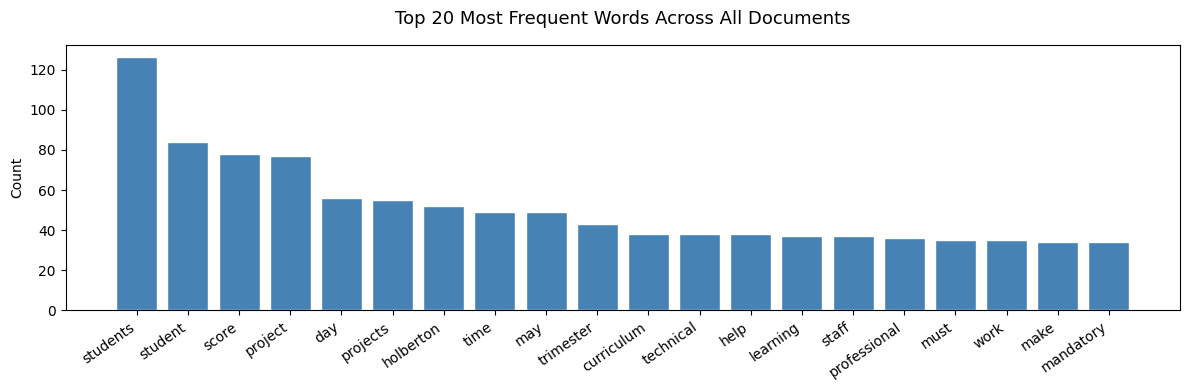


Document  : AcademicStanding.md
────────────────────────────────────────────────────────────
Raw text  (203 words):
Holberton strives to be a supportive learning space with clear expectations. This is an intense program and in order to maintain an equitable and cooperative space, you need to know ...

Cleaned   (105 tokens):
holberton strives supportive learning space clear expectations intense program order maintain equitable cooperative space need know protocol resources surrounding performance academic score holberton monitored throughout year benchmarks set midnight sunday ...


In [ ]:
# ── Preprocessing ─────────────────────────────────────────────────────────────

STOP_WORDS = set(stopwords.words('english'))

def preprocess(text):
    """Clean a raw markdown document into a list of meaningful tokens."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove markdown headings, bold, italic, URLs, and punctuation
    text = re.sub(r'http\S+',        '', text)   # URLs
    text = re.sub(r'[#*_>\-`]',      '', text)   # markdown symbols
    text = re.sub(r'[^a-z\s]',       '', text)   # punctuation & numbers
    text = re.sub(r'\s+',            ' ', text)  # extra whitespace
    # 3. Tokenize
    tokens = text.strip().split()
    # 4. Remove stop words and very short tokens
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return tokens

# Apply to every document and store cleaned text alongside raw
for doc in corpus:
    doc['tokens'] = preprocess(doc['text'])
    doc['clean_text'] = ' '.join(doc['tokens'])

# ── Vocabulary Overview ───────────────────────────────────────────────────────

all_tokens = [t for doc in corpus for t in doc['tokens']]
vocab      = sorted(set(all_tokens))

print(f"✓ Total tokens (with repetition) : {len(all_tokens):,}")
print(f"✓ Unique vocabulary size         : {len(vocab):,}")
print(f"✓ Average tokens per document    : {int(len(all_tokens) / len(corpus))}")

# ── Top 20 Most Frequent Words ────────────────────────────────────────────────

from collections import Counter

freq   = Counter(all_tokens)
top_20 = freq.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(12, 4))
bars = plt.bar(words, counts, color='steelblue', edgecolor='white')
plt.title('Top 20 Most Frequent Words Across All Documents', fontsize=13, pad=15)
plt.ylabel('Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# ── Before / After on One Document ───────────────────────────────────────────

sample = corpus[0]
print(f"\nDocument  : {sample['filename']}")
print(f"{'─'*60}")
print(f"Raw text  ({len(sample['text'].split())} words):")
print(' '.join(sample['text'].split()[:30]), '...')
print(f"\nCleaned   ({len(sample['tokens'])} tokens):")
print(' '.join(sample['tokens'][:30]), '...')

## Step 2: Bag of Words

The simplest way to turn text into numbers. We build a matrix where:
- Each **row** is a document
- Each **column** is a word from the vocabulary
- Each **cell** is the count of how many times that word appears in that document

The result is called a **document-term matrix**. With 91 documents and ~2,298
unique words, our matrix will be 91 × 2,298 — but most cells will be **zero**,
because most words only appear in a handful of documents.

We will then use this matrix to answer a real question:
> *"Which documents are most similar to each other — just by counting words?"*

✓ BoW matrix shape: (91, 500)  (documents × features)
✓ Sparsity: 92.3% zeros

Top 5 words by count for sample documents:

  AcademicStanding          → 'technical' (3),  'month' (3),  'holberton' (3),  'program' (3),  'nature' (2)
  Cheating-Overview         → 'work' (3),  'others' (3),  'cheating' (3),  'holberton' (3),  'code' (2)
  ChiefKitchenOfficer       → 'kitchen' (5),  'must' (5),  'day' (4),  'food' (4),  'chief' (3)
  CurriculumFAQ2            → 'thinking' (3),  'see' (2),  'problem' (2),  'part' (2),  'would' (1)
  Events                    → 'may' (3),  'get' (2),  'projects' (2),  'new' (2),  'students' (2)


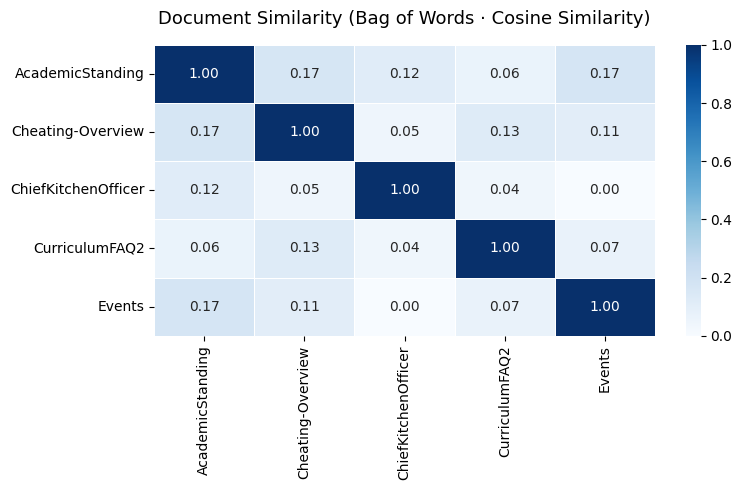


── The order problem ────────────────────────────────────────────
  Sentence A : 'students must maintain academic performance'
  Sentence B : 'academic performance must maintain students'
  BoW similarity score : 1.00  ← identical, despite different meaning


In [ ]:
# ── Bag of Words Matrix ───────────────────────────────────────────────────────

bow_vectorizer = CountVectorizer(max_features=500)
bow_matrix     = bow_vectorizer.fit_transform([doc['clean_text'] for doc in corpus])
bow_features   = bow_vectorizer.get_feature_names_out()

print(f"✓ BoW matrix shape: {bow_matrix.shape}  (documents × features)")
print(f"✓ Sparsity: {100 * (1 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1])):.1f}% zeros")

# ── Readable Sample: Top Words per Document ───────────────────────────────────

bow_df = pd.DataFrame(bow_matrix.toarray(),
                      columns=bow_features,
                      index=[doc['filename'].replace('.md','') for doc in corpus])

# Show top 5 words for 5 sample documents
sample_docs = ['AcademicStanding', 'Cheating-Overview',
               'ChiefKitchenOfficer', 'CurriculumFAQ2', 'Events']
sample_df   = bow_df.loc[[d for d in sample_docs if d in bow_df.index]]

print("\nTop 5 words by count for sample documents:\n")
for doc_name, row in sample_df.iterrows():
    top5 = row.sort_values(ascending=False).head(5)
    top5_str = ',  '.join([f"'{w}' ({int(c)})" for w, c in top5.items()])
    print(f"  {doc_name:<25} → {top5_str}")

# ── Document Similarity Heatmap ───────────────────────────────────────────────

similarity = cosine_similarity(bow_matrix)
sim_df     = pd.DataFrame(similarity,
                          index=[doc['filename'].replace('.md','') for doc in corpus],
                          columns=[doc['filename'].replace('.md','') for doc in corpus])

# Plot only our 5 sample documents for clarity
sample_sim = sim_df.loc[sample_docs, sample_docs]

plt.figure(figsize=(8, 5))
sns.heatmap(sample_sim,
            annot=True, fmt='.2f',
            cmap='Blues',
            linewidths=0.5,
            vmin=0, vmax=1)
plt.title('Document Similarity (Bag of Words · Cosine Similarity)', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# ── The Problem: Order is Invisible ──────────────────────────────────────────

print("\n── The order problem ────────────────────────────────────────────")
test_sentences = [
    "students must maintain academic performance",
    "academic performance must maintain students",
]
test_matrix = bow_vectorizer.transform(test_sentences)
score = cosine_similarity(test_matrix[0], test_matrix[1])[0][0]
print(f"  Sentence A : '{test_sentences[0]}'")
print(f"  Sentence B : '{test_sentences[1]}'")
print(f"  BoW similarity score : {score:.2f}  ← identical, despite different meaning")

## Step 3: TF-IDF — Not All Words Matter Equally

Bag of Words treats every word the same. But a word like `"holberton"` that
appears in every document tells us nothing about what makes any specific
document unique. A word like `"fridge"` that appears in only one document
tells us everything about it.

**TF-IDF** fixes this by assigning each word a weight that balances two forces:

- **TF (Term Frequency):** How often the word appears in *this* document
- **IDF (Inverse Document Frequency):** How rare the word is *across all documents*

The result: common words get penalized, rare distinctive words get rewarded.

We will use the same corpus and answer two questions:
> *"What is each document really about?"* — via top TF-IDF keywords
> *"Does smarter weighting produce better similarity scores?"* — via heatmap

✓ TF-IDF matrix shape: (91, 500)  (documents × features)

Top 5 keywords by TF-IDF weight for sample documents:

  AcademicStanding          → 'month' (0.38),  'program' (0.25),  'average' (0.23),  'nature' (0.23),  'technical' (0.22)
  Cheating-Overview         → 'cheating' (0.46),  'others' (0.36),  'work' (0.29),  'holberton' (0.25),  'code' (0.21)
  ChiefKitchenOfficer       → 'kitchen' (0.47),  'food' (0.38),  'chief' (0.27),  'must' (0.26),  'officer' (0.25)
  CurriculumFAQ2            → 'thinking' (0.46),  'problem' (0.29),  'part' (0.25),  'see' (0.22),  'ability' (0.16)
  Events                    → 'events' (0.33),  'may' (0.27),  'opportunity' (0.26),  'new' (0.25),  'get' (0.24)


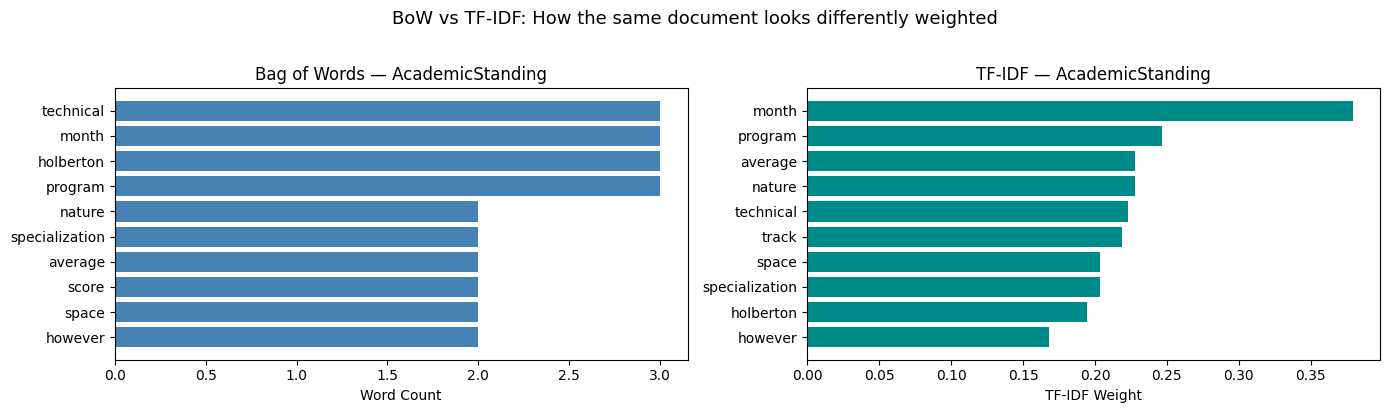

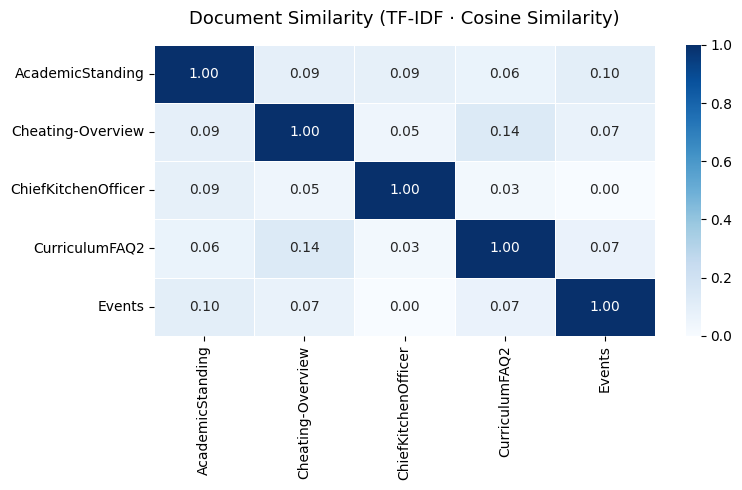


── The meaning problem ──────────────────────────────────────────────

  A : 'students must maintain academic performance'
  B : 'learners need to keep up their grades'
  TF-IDF similarity : 0.00  ← near zero despite same meaning

  A : 'cheating will not be tolerated'
  B : 'plagiarism leads to expulsion'
  TF-IDF similarity : 0.00  ← near zero despite same meaning


In [ ]:
# ── TF-IDF Matrix ─────────────────────────────────────────────────────────────

tfidf_vectorizer = TfidfVectorizer(max_features=500)
tfidf_matrix     = tfidf_vectorizer.fit_transform([doc['clean_text'] for doc in corpus])
tfidf_features   = tfidf_vectorizer.get_feature_names_out()

print(f"✓ TF-IDF matrix shape: {tfidf_matrix.shape}  (documents × features)")

# ── Top Keywords Per Document ─────────────────────────────────────────────────

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(),
                        columns=tfidf_features,
                        index=[doc['filename'].replace('.md','') for doc in corpus])

sample_docs = ['AcademicStanding', 'Cheating-Overview',
               'ChiefKitchenOfficer', 'CurriculumFAQ2', 'Events']

print("\nTop 5 keywords by TF-IDF weight for sample documents:\n")
for doc_name in sample_docs:
    if doc_name in tfidf_df.index:
        top5     = tfidf_df.loc[doc_name].sort_values(ascending=False).head(5)
        top5_str = ',  '.join([f"'{w}' ({v:.2f})" for w, v in top5.items()])
        print(f"  {doc_name:<25} → {top5_str}")

# ── BoW vs TF-IDF Weight Comparison ──────────────────────────────────────────

# Pick one document and compare how BoW and TF-IDF weight its top words
focus_doc  = 'AcademicStanding'
bow_row    = bow_df.loc[focus_doc].sort_values(ascending=False).head(10)
tfidf_row  = tfidf_df.loc[focus_doc].sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(bow_row.index[::-1],   bow_row.values[::-1],   color='steelblue')
axes[0].set_title(f'Bag of Words — {focus_doc}', fontsize=12)
axes[0].set_xlabel('Word Count')

axes[1].barh(tfidf_row.index[::-1], tfidf_row.values[::-1], color='darkcyan')
axes[1].set_title(f'TF-IDF — {focus_doc}', fontsize=12)
axes[1].set_xlabel('TF-IDF Weight')

plt.suptitle('BoW vs TF-IDF: How the same document looks differently weighted',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Similarity Heatmap ────────────────────────────────────────────────────────

tfidf_sim    = cosine_similarity(tfidf_matrix)
tfidf_sim_df = pd.DataFrame(tfidf_sim,
                             index=[doc['filename'].replace('.md','') for doc in corpus],
                             columns=[doc['filename'].replace('.md','') for doc in corpus])

sample_sim_tfidf = tfidf_sim_df.loc[sample_docs, sample_docs]

plt.figure(figsize=(8, 5))
sns.heatmap(sample_sim_tfidf,
            annot=True, fmt='.2f',
            cmap='Blues',
            linewidths=0.5,
            vmin=0, vmax=1)
plt.title('Document Similarity (TF-IDF · Cosine Similarity)', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# ── The Remaining Problem: Meaning is Still Invisible ─────────────────────────

print("\n── The meaning problem ──────────────────────────────────────────────")
semantic_pairs = [
    ("students must maintain academic performance",
     "learners need to keep up their grades"),
    ("cheating will not be tolerated",
     "plagiarism leads to expulsion"),
]
for s1, s2 in semantic_pairs:
    vecs  = tfidf_vectorizer.transform([s1, s2])
    score = cosine_similarity(vecs[0], vecs[1])[0][0]
    print(f"\n  A : '{s1}'")
    print(f"  B : '{s2}'")
    print(f"  TF-IDF similarity : {score:.2f}  ← near zero despite same meaning")

## Step 4: N-grams — Capturing Local Word Order

Both BoW and TF-IDF treat documents as unordered bags of words. The phrase
`"not good"` and the phrase `"good not"` produce identical vectors — which
is a serious problem for any task where word order carries meaning.

**N-grams** fix this by treating *sequences* of consecutive words as single
features rather than individual words.

- **Unigrams (n=1):** `"academic"`, `"performance"`, `"score"`
- **Bigrams (n=2):** `"academic performance"`, `"performance score"`
- **Trigrams (n=3):** `"academic performance score"`

We will observe two things:
> *"Do bigrams extract more meaningful phrases from our documents?"*
> *"What happens to vocabulary size as n grows?"* — the explosion problem

Vocabulary sizes (capped at 500 features):

  Unigrams     →  2298 unique n-grams  (matrix with cap: (91, 500))
  Bigrams      →  6967 unique n-grams  (matrix with cap: (91, 500))
  Trigrams     →  7633 unique n-grams  (matrix with cap: (91, 500))
  Uni+Bi       →  9265 unique n-grams  (matrix with cap: (91, 500))


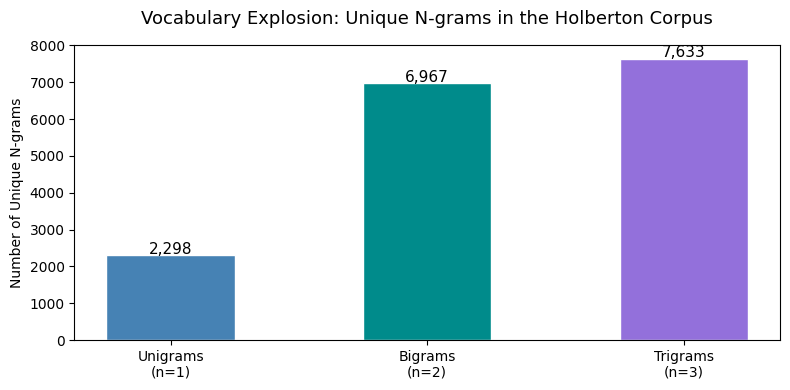


Top 5 bigrams per document:

  ChiefOfficerDuties        → 'professional score' (3),  'officer chief' (3),  'chief officer' (3),  'chief officers' (3),  'receive professional' (2)
  ChiefKitchenOfficer       → 'duties chief' (2),  'chief kitchen' (2),  'kitchen officer' (2),  'must cleaned' (2),  'responsibility make' (1)
  CurriculumFAQ             → 'task complete' (1),  'curriculum faq' (1),  'overnight requires' (1),  'people arent' (1),  'often times' (1)
  CurriculumFAQ2            → 'would like' (1),  'curriculum faq' (1),  'years come' (1),  'edge cases' (1),  'software engineer' (1)
  CurriculumOverview        → 'throughout careers' (1),  'technical skills' (1),  'need support' (1),  'years come' (1),  'technical professional' (1)


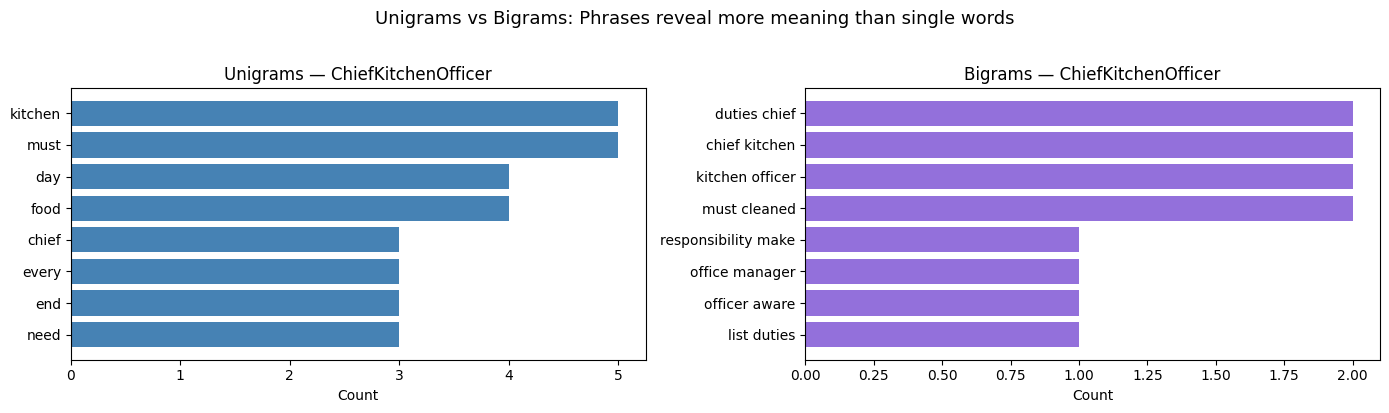

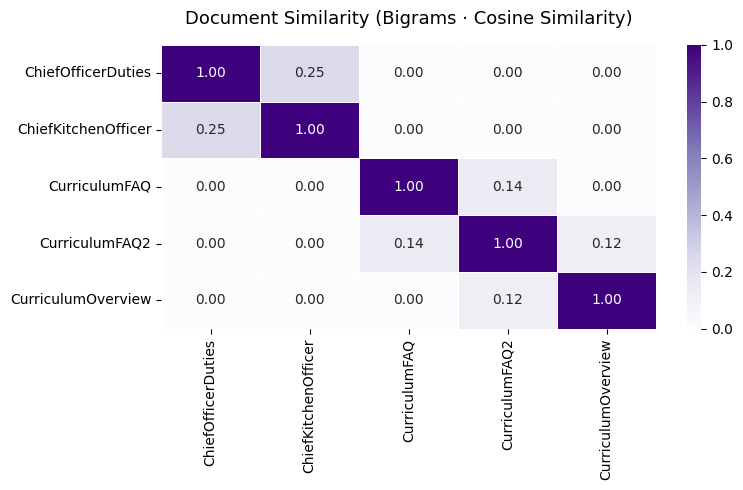


── What bigrams still miss ───────────────────────────────────────────
  'kitchen clean' and 'clean kitchen' are still different features.
  'students must maintain performance' and
  'learners need to keep up grades' still score zero.

  Next: we stop counting and start learning — Word Embeddings.


In [ ]:
# ── N-gram Vectorizers ────────────────────────────────────────────────────────

vectorizers = {
    'Unigrams'  : CountVectorizer(ngram_range=(1, 1), max_features=500),
    'Bigrams'   : CountVectorizer(ngram_range=(2, 2), max_features=500),
    'Trigrams'  : CountVectorizer(ngram_range=(3, 3), max_features=500),
    'Uni+Bi'    : CountVectorizer(ngram_range=(1, 2), max_features=500),
}

clean_texts = [doc['clean_text'] for doc in corpus]
matrices    = {}

print("Vocabulary sizes (capped at 500 features):\n")
for name, vec in vectorizers.items():
    mat            = vec.fit_transform(clean_texts)
    matrices[name] = (mat, vec)
    # Count uncapped vocabulary
    full_vec       = CountVectorizer(ngram_range=vec.ngram_range)
    full_mat       = full_vec.fit_transform(clean_texts)
    print(f"  {name:<12} → {full_mat.shape[1]:>5} unique n-grams  "
          f"(matrix with cap: {mat.shape})")

# ── Vocabulary Explosion Chart ────────────────────────────────────────────────

ngram_labels = ['Unigrams\n(n=1)', 'Bigrams\n(n=2)', 'Trigrams\n(n=3)']
ngram_sizes  = []

for ngram_range in [(1,1), (2,2), (3,3)]:
    v = CountVectorizer(ngram_range=ngram_range)
    m = v.fit_transform(clean_texts)
    ngram_sizes.append(m.shape[1])

plt.figure(figsize=(8, 4))
bars = plt.bar(ngram_labels, ngram_sizes,
               color=['steelblue', 'darkcyan', 'mediumpurple'],
               edgecolor='white', width=0.5)
for bar, size in zip(bars, ngram_sizes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{size:,}', ha='center', fontsize=11)
plt.title('Vocabulary Explosion: Unique N-grams in the Holberton Corpus',
          fontsize=13, pad=15)
plt.ylabel('Number of Unique N-grams')
plt.tight_layout()
plt.show()

# ── Top Bigrams Per Document ──────────────────────────────────────────────────

bi_mat, bi_vec = matrices['Bigrams']
bi_features    = bi_vec.get_feature_names_out()
bi_df          = pd.DataFrame(bi_mat.toarray(),
                               columns=bi_features,
                               index=[doc['filename'].replace('.md','')
                                      for doc in corpus])

sample_docs = ['ChiefOfficerDuties', 'ChiefKitchenOfficer',
               'CurriculumFAQ', 'CurriculumFAQ2', 'CurriculumOverview']

print("\nTop 5 bigrams per document:\n")
for doc_name in sample_docs:
    if doc_name in bi_df.index:
        top5     = bi_df.loc[doc_name].sort_values(ascending=False).head(5)
        top5_str = ',  '.join([f"'{w}' ({int(c)})" for w, c in top5.items()])
        print(f"  {doc_name:<25} → {top5_str}")

# ── Unigram vs Bigram: Side by Side on One Document ──────────────────────────

focus_doc   = 'ChiefKitchenOfficer'
uni_mat, uni_vec = matrices['Unigrams']
uni_features     = uni_vec.get_feature_names_out()
uni_df           = pd.DataFrame(uni_mat.toarray(),
                                 columns=uni_features,
                                 index=[doc['filename'].replace('.md','')
                                        for doc in corpus])

uni_top = uni_df.loc[focus_doc].sort_values(ascending=False).head(8)
bi_top  = bi_df.loc[focus_doc].sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(uni_top.index[::-1], uni_top.values[::-1], color='steelblue')
axes[0].set_title(f'Unigrams — {focus_doc}', fontsize=12)
axes[0].set_xlabel('Count')

axes[1].barh(bi_top.index[::-1], bi_top.values[::-1], color='mediumpurple')
axes[1].set_title(f'Bigrams — {focus_doc}', fontsize=12)
axes[1].set_xlabel('Count')

plt.suptitle('Unigrams vs Bigrams: Phrases reveal more meaning than single words',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Similarity Heatmap with Bigrams ──────────────────────────────────────────

bi_sim    = cosine_similarity(bi_mat)
bi_sim_df = pd.DataFrame(bi_sim,
                          index=[doc['filename'].replace('.md','') for doc in corpus],
                          columns=[doc['filename'].replace('.md','') for doc in corpus])

sample_sim_bi = bi_sim_df.loc[sample_docs, sample_docs]

plt.figure(figsize=(8, 5))
sns.heatmap(sample_sim_bi,
            annot=True, fmt='.2f',
            cmap='Purples',
            linewidths=0.5,
            vmin=0, vmax=1)
plt.title('Document Similarity (Bigrams · Cosine Similarity)', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print("\n── What bigrams still miss ───────────────────────────────────────────")
print("  'kitchen clean' and 'clean kitchen' are still different features.")
print("  'students must maintain performance' and")
print("  'learners need to keep up grades' still score zero.")
print("\n  Next: we stop counting and start learning — Word Embeddings.")

## Summary: What We Learned — and What We Still Can't Do

We have now applied three foundational NLP techniques to a real corpus of
91 Holberton School documents. Before moving on, let's take stock of what
each method gave us — and where each one broke down.


### What We Built

| Technique | What It Produces | Best Use Case |
|---|---|---|
| Bag of Words | Word count matrix | Quick baseline, keyword detection |
| TF-IDF | Weighted count matrix | Keyword extraction, document search |
| N-grams | Sequence count matrix | Phrase detection, local context |


### What We Confirmed on Real Data

- **BoW** correctly identified that `"ChiefKitchenOfficer"` is about kitchens
  and `"Cheating-Overview"` is about plagiarism — just from raw word counts
- **TF-IDF** sharpened those signals dramatically: generic words like
  `"holberton"` and `"student"` were penalized, while distinctive words like
  `"fridge"`, `"plagiarism"`, and `"trimester"` rose to the top
- **Bigrams** revealed meaningful phrases invisible to single-word methods:
  `"coffee machine"`, `"academic score"`, `"critical thinking"` — each one
  more informative than any single word alone


### The Wall We Hit — Every Time

Despite three different techniques, the same fundamental failure appeared
in every section:

`"students must maintain academic performance"`

`"learners need to keep up their grades"`

Similarity score → 0.00`

These two sentences mean the same thing. A human reads them and immediately
understands they are equivalent. But every method we tried scored them as
completely unrelated — because they share no words in common.

This is not a bug in our implementation. It is a fundamental limitation of
**counting-based methods**. They can only see what is literally written.
They have no concept of meaning, synonymy, or context.


### The Three Ceilings

**1. No Semantic Understanding**
`"cheating"` and `"plagiarism"` are treated as completely unrelated words.
The model has no way to know that both describe academic dishonesty, appear
in identical contexts throughout our corpus, and are often interchangeable
in meaning. Equally, `"students"` and `"learners"` score zero similarity —
despite referring to the exact same people in the exact same situation.

**2. No Word Order Beyond N-grams**
Even with trigrams, the global structure of a sentence is lost.
A question and its answer can look identical in a bag-of-words world.

**3. Sparsity**
Our matrices are over 90% zeros. Most documents say nothing about most words.
This is computationally wasteful and statistically fragile — rare words
that appear once carry unreliable signal.


### The Question That Opens Notebook 2

> What if instead of counting words, we *learned* a representation from data?
> What if similar words ended up close together in a mathematical space —
> so that `"learners"` and `"students"` were neighbors,
> and `"maintain"` and `"keep up"` pointed in the same direction?

That is exactly what **word embeddings** do.

In Notebook 2 we will train Word2Vec and load GloVe and fastText on this
same corpus — and for the first time, we will be able to *see* meaning
as geometry in a two-dimensional plot of real words from these documents.

